## División del corups por párrafos

### Librerías

In [1]:
import spacy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


import json
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity


import nltk
from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize
from sentence_transformers import SentenceTransformer
from umap import UMAP


from sentence_transformers import CrossEncoder
from scipy.special import expit


import re
from nltk.tokenize import word_tokenize
from sklearn.preprocessing import StandardScaler

nltk.download("punkt")
nltk.download('stopwords')
nlp = spacy.load("es_core_news_sm")
stop = stopwords.words('spanish')

/home/javier/miniconda3/envs/NLP/lib/python3.12/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/home/javier/miniconda3/envs/NLP/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
I0000 00:00:1778575175.623115   25810 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778575177.012942   25810 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
[nltk_data] Downloading package punkt to /home/javier/nltk_data...
[nltk_data]   Package punk

### Funciones principales

In [2]:


def cargar_datos(noticias, n_noticia=0, print_info=False):
    """
    Carga título y contenido de una noticia
    input: n_noticia (int): índice de noticia
    output: titulo, fragmentos_contenido (list)
    """
    noticia = noticias[n_noticia]
    titulo = noticia["Título"]
    contenido = noticia["Contenido"]
    fragmentos_contenido = sent_tokenize(contenido, language='spanish')
    
    if print_info:
        print(f"Título: {titulo}\n")
        print(f"\nFragmentos:")
        for i, frag in enumerate(fragmentos_contenido, 1):
            print(f"  Fragmento {i}: {frag}")
    
    return titulo, fragmentos_contenido,noticia


def extraer_features_linguisticos(corpus):
    """
    Extrae features lingüísticas relacionadas con clickbait.

    Parameters
    ----------
    corpus : list[str]
        Lista de textos.

    Returns
    -------
    np.ndarray
        Array shape (n_textos, n_features)
    """

    # =====================================================
    # Diccionarios léxicos
    # =====================================================

    deicticos = {
        'yo', 'tú', 'tu', 'usted', 'ustedes',
        'él', 'ella', 'ellos', 'ellas',
        'nosotros', 'nosotras',
        'vosotros', 'vosotras',
        'me', 'te', 'se', 'nos', 'os',
        'le', 'les',
        'mi', 'mis',
        'tus', 'su', 'sus',
        'nuestro', 'nuestra',
        'vuestro', 'vuestra',
        'este', 'esta', 'estos', 'estas',
        'ese', 'esa', 'esos', 'esas',
        'aquel', 'aquella',
        'aquí', 'ahí', 'allí',
        'ahora', 'hoy', 'mañana',
        'esto', 'eso', 'aquello'
    }

    intensificadores = {
        'muy', 'sumamente', 'extremadamente',
        'increíblemente', 'absolutamente',
        'totalmente', 'completamente',
        'realmente', 'verdaderamente',
        'demasiado', 'especialmente',
        'particularmente', 'sorprendentemente',
        'brutalmente', 'impresionantemente',
        'enormemente', 'terriblemente'
    }

    superlativos = {
        'mejor', 'peor', 'máximo', 'mínimo',
        'mayor', 'menor', 'último', 'primero',
        'buenísimo', 'malísimo',
        'importantísimo', 'gravísimo',
        'rarísimo', 'famosísimo',
        'enormísimo'
    }

    emocionales = {
        'increíble', 'impactante',
        'sorprendente', 'brutal',
        'impresionante', 'escandaloso',
        'alarmante', 'insólito',
        'inesperado', 'viral',
        'polémico', 'emocionante',
        'dramático', 'sorprendido',
        'devastador', 'terrible',
        'histórico', 'explosivo'
    }

    curiosity_gap = {
        'no creerás',
        'nadie esperaba',
        'lo que pasó',
        'te sorprenderá',
        'se vuelve viral',
        'está arrasando',
        'deja sin palabras',
        'causa furor',
        'no podrás creer',
        'todo el mundo habla',
        'revoluciona las redes',
        'se hace viral'
    }

    # =====================================================
    # Extracción de features
    # =====================================================

    features = []

    for texto in corpus:

        texto_lower = texto.lower()

        palabras = word_tokenize(
            texto_lower,
            language="spanish"
        )

        n_palabras = max(len(palabras), 1)

        # -----------------------------
        # Conteos léxicos
        # -----------------------------

        deicticos_count = sum(
            1 for p in palabras
            if p in deicticos
        )

        intensificadores_count = sum(
            1 for p in palabras
            if p in intensificadores
        )

        emocionales_count = sum(
            1 for p in palabras
            if p in emocionales
        )

        superlativos_count = sum(
            1 for p in palabras
            if (
                p in superlativos
                or any(
                    suf in p
                    for suf in [
                        'ísimo',
                        'ísima',
                        'ísimos',
                        'ísimas'
                    ]
                )
            )
        )

        # -----------------------------
        # Curiosity gap
        # -----------------------------

        curiosity_count = sum(
            1 for expr in curiosity_gap
            if expr in texto_lower
        )

        # -----------------------------
        # Puntuación
        # -----------------------------

        exclamaciones = len(
            re.findall(r'[!¡]', texto)
        )

        interrogaciones = len(
            re.findall(r'[?¿]', texto)
        )

        puntos_suspensivos = texto.count("...")

        mayusculas = len(
            re.findall(r'\b[A-ZÁÉÍÓÚÑ]{2,}\b', texto)
        )

        numeros = len(
            re.findall(r'\b\d+\b', texto)
        )

        # -----------------------------
        # Ratios normalizados
        # -----------------------------

        deicticos_ratio = deicticos_count / n_palabras
        intensificadores_ratio = intensificadores_count / n_palabras
        emocionales_ratio = emocionales_count / n_palabras
        superlativos_ratio = superlativos_count / n_palabras

        # -----------------------------
        # Vector final
        # -----------------------------

        features.append([
            deicticos_count,
            intensificadores_count,
            superlativos_count,
            emocionales_count,
            curiosity_count,
            exclamaciones,
            interrogaciones,
            # puntos_suspensivos,
            # mayusculas,
            # numeros,
            deicticos_ratio,
            intensificadores_ratio,
            emocionales_ratio,
            superlativos_ratio
        ])

    return np.array(features)


def calcular_diferencia_features(corpus):
    """
    Calcula diferencia de features entre título y fragmentos
    input: corpus (list): lista de textos
    output: diferencias (array), features normalizados (tuple)
    """
    
    features = extraer_features_linguisticos(corpus)
    
    scaler = StandardScaler()
    features_norm = scaler.fit_transform(features)
    
    titulo_norm = features_norm[0]
    fragmentos_norm = features_norm[1:]
    
    diferencias = np.linalg.norm(fragmentos_norm - titulo_norm, axis=1)
    
    return diferencias, (titulo_norm, fragmentos_norm)


# =========================
# LSA (reducción a 2D)
# =========================

def LSA_vectors(corpus,min_df=1,plot=False):
    tfidf_vectorizer = TfidfVectorizer(min_df=min_df)
    tfidf = tfidf_vectorizer.fit_transform(corpus)


    n_components = min(2, tfidf.shape[0] - 1)
    lsa = TruncatedSVD(n_components=n_components, random_state=42)
    tfidf_lsa = lsa.fit_transform(tfidf)
    titulo_vector = tfidf[0]
    fragmentos_vectors = tfidf[1:]
    similitudes = cosine_similarity(titulo_vector, fragmentos_vectors)[0]
    # if plot:
    #     plt.figure(figsize=(10, 6))
    #     colors = ['red'] + ['blue'] * len(fragmentos_contenido)
    #     labels = ['Título'] + [f'Frag {i+1}' for i in range(len(fragmentos_contenido))]

    #     plt.scatter(tfidf_lsa[:, 0], tfidf_lsa[:, 1], c=colors, s=100, alpha=0.6)
    #     for i, label in enumerate(labels):
    #         plt.annotate(label, (tfidf_lsa[i, 0], tfidf_lsa[i, 1]), fontsize=9, ha='center')

    #     plt.xlabel('LSA Component 1')
    #     plt.ylabel('LSA Component 2')
    #     plt.title('Distribución LSA: Título vs Fragmentos')
    #     plt.grid(True, alpha=0.3)
    #     plt.tight_layout()
    #     plt.show()

    return similitudes,tfidf_lsa



# ----------------------------
# ESPACIO EMBEDDING CON SENTENCE TRANSFORMERS
# ----------------------------


def embedding_sentence_transformers(corpus):
    embedding_model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-mpnet-base-v2") # paraphrase-multilingual-mpnet-base-v2 paraphrase-multilingual-MiniLM-L12-v2
    embeddings = embedding_model.encode(
    corpus,
    show_progress_bar=True
    )
    titulo_embedding = embeddings[0]
    fragmentos_embeddings = embeddings[1:]

    similarities = cosine_similarity(
        [titulo_embedding],
        fragmentos_embeddings
    )[0]

    return similarities,embeddings

def embedding_umap(similarities,embeddings, plot=False):
    reducer = UMAP(
    n_neighbors = min(5, len(embeddings) - 1), # Pongo esto porque a veces hay tan pocos que da error
    n_components=2,
    init="random",
    min_dist=0.1,
    metric="cosine",
    random_state=42
    )
    embedding_2d = reducer.fit_transform(embeddings)
    if plot:
        x = embedding_2d[:, 0]
        y = embedding_2d[:, 1]

        plt.figure(figsize=(10, 8))

        # Fragmentos
        scatter = plt.scatter(
            x[1:],
            y[1:],
            c=similarities,
            cmap="viridis",
            s=80,
            alpha=0.8
        )

        # Título
        plt.scatter(
            x[0],
            y[0],
            color="red",
            s=250,
            marker="X",
            label="Título"
        )

        # Etiquetas opcionales
        for i, (xi, yi) in enumerate(zip(x[1:], y[1:])):
            plt.text(
                xi,
                yi,
                str(i + 1),
                fontsize=8
            )

        plt.colorbar(
            scatter,
            label="Similitud coseno con título"
        )

        plt.title("Espacio semántico de la noticia")
        plt.xlabel("UMAP-1")
        plt.ylabel("UMAP-2")

        plt.legend()
        plt.grid(alpha=0.2)

        plt.show()
    return embedding_2d


def embedding_cross_encoder(corpus):
    cross_encoder = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")
    pairs = [[corpus[0], fragmento] for fragmento in corpus[1:]]
    scores = cross_encoder.predict(pairs)
    probabilities = expit(scores)
    return probabilities


In [3]:
# Cargar datos una sola vez
with open("conjunto_noticias/conjunto_noticias_limpio.json", "r", encoding="utf-8") as f:
    noticias = json.load(f)


In [4]:
titulo, fragmentos_contenido,noticia=cargar_datos(noticias, n_noticia=5, print_info=False)
corpus = [titulo] + fragmentos_contenido

# Análisis exploratorio de los datos

In [5]:
import pandas as pd

df = pd.DataFrame(noticias)

df.head()

,Link,Periódico,Fecha,Título,Subtítulo,Categoría,Contenido,cb,cb_score,cb_label
0,https://www.20minutos.es/internacional/musk-so...,20minutos,2026-04-29,musk sostiene que fue engañado por openai al a...,los ángeles ee.uu. 28 abr efe. el magnate tecn...,Internacional,el magnate tecnológico elon musk ha declarado ...,False,1.0000,NO Clickbait
1,https://www.20minutos.es/internacional/senado-...,20minutos,2026-04-29,el senado de eeuu falla en su intento de limit...,con una votación de 47 votos a favor y 51 en c...,Internacional,los demócratas del senado de estados unidos ha...,False,1.0000,NO Clickbait
2,https://www.20minutos.es/internacional/sur-lib...,20minutos,2026-04-29,en el sur del líbano todo el mundo tiene el co...,la invasión terrestre de las fuerzas israelíes...,Internacional,el tráfico avanza lentamente hacia el sur del ...,False,0.9735,NO Clickbait
3,https://www.20minutos.es/nacional/iglesias-den...,20minutos,2026-04-28,iglesias critica que la jueza que le instó a d...,el incidente ocurrió el 4 de marzo cuando la m...,Nacional,el fundador de podemos y exministro de derecho...,False,0.7833,NO Clickbait
4,https://www.20minutos.es/nacional/presidente-t...,20minutos,2026-04-28,el presidente del tedh defiende en el supremo ...,la máxima autoridad del organismo europeo ha p...,Nacional,el presidente del tribunal europeo de derechos...,False,1.0000,NO Clickbait


Proporción de clickbait por periódico

In [6]:
clickbait_ratio = df.groupby("Periódico")["cb"].mean().sort_values(ascending=False)
print(clickbait_ratio)

Periódico
Huffingtonpost          0.900000
Eldiario                0.444444
20minutos               0.333333
El Confidencial         0.333333
RTVE                    0.333333
La Vanguardia           0.222222
okdiario                0.111111
Mediterraneo Digital    0.100000
ABC                     0.000000
Name: cb, dtype: float64


In [7]:
clickbait_ratio = df.groupby("Categoría")["cb"].mean().sort_values(ascending=False)
print(clickbait_ratio) # CAMBIAR EL "internacional" y "VIRALES" POR CULTURA

Categoría
virales          0.900000
Cultura          0.333333
Nacional         0.238095
Internacional    0.190476
internacional    0.100000
Name: cb, dtype: float64


In [9]:
summary = df.groupby("Periódico").agg(
    total=("cb", "count"),
    clickbait=("cb", "sum"),
    ratio=("cb", "mean")
).sort_values("ratio", ascending=False)
summary

,total,clickbait,ratio
Periódico,,,
Huffingtonpost,10,9,0.900000
Eldiario,9,4,0.444444
20minutos,9,3,0.333333
El Confidencial,9,3,0.333333
RTVE,9,3,0.333333
La Vanguardia,9,2,0.222222
okdiario,9,1,0.111111
Mediterraneo Digital,10,1,0.100000
ABC,9,0,0.000000


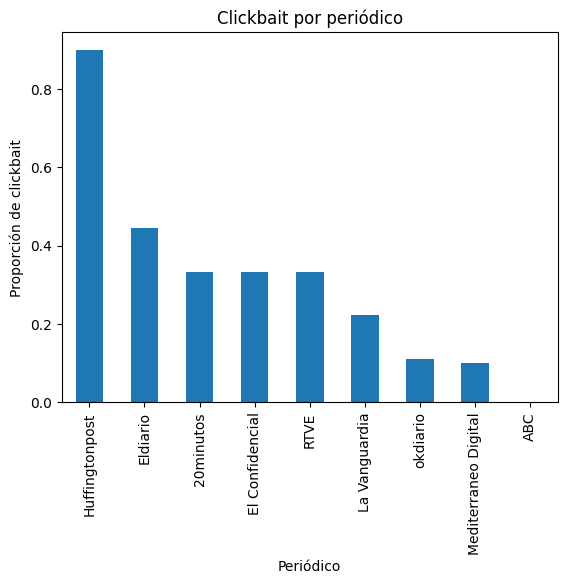

In [10]:
import matplotlib.pyplot as plt

summary["ratio"].plot(kind="bar")
plt.ylabel("Proporción de clickbait")
plt.title("Clickbait por periódico")
plt.show()

In [ ]:
df["len_titulo"] = df["Título"].str.len()
df.groupby("cb")["len_titulo"].describe()

,count,mean,std,min,25%,50%,75%,max
cb,,,,,,,,
False,57.0,85.929825,21.712291,31.0,72.00,85.0,103.00,153.0
True,26.0,87.038462,33.903959,4.0,61.75,89.5,107.75,139.0


### LSA

In [5]:
# corpus=cargar_datos(1)
similitudes,tfidf_lsa=LSA_vectors(corpus,min_df=2)


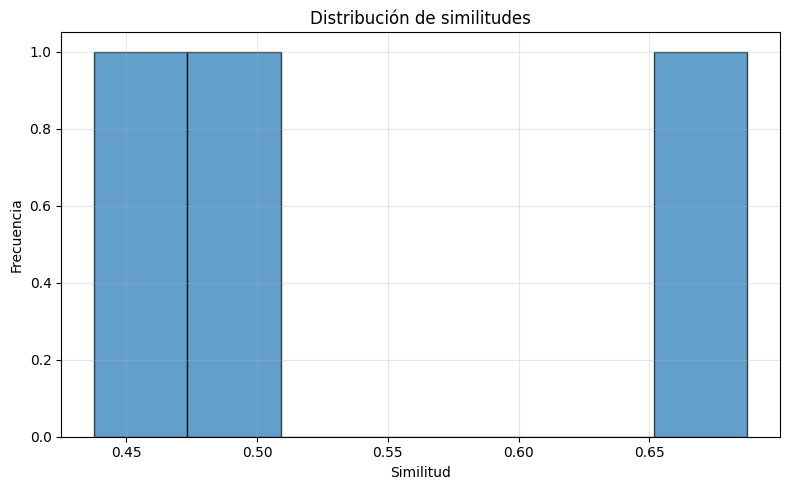

In [6]:
plt.figure(figsize=(8, 5))

plt.hist(
    similitudes,
    bins=7,          # Número de bins
    edgecolor='black',
    alpha=0.7
)

plt.xlabel("Similitud")
plt.ylabel("Frecuencia")
plt.title("Distribución de similitudes")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Embeding semántico

Aplicar:Crear un vector adicional de features de decticos, puntuación, superlativos. Si el embeding cae en una zona del espacio muy cargada de adjetivos pero el cuerpo está en una zona neutral, esa diferencia puede ser indicios de clickbait.

Batches: 100%|██████████| 1/1 [00:00<00:00,  1.63it/s]
/home/javier/miniconda3/envs/NLP/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


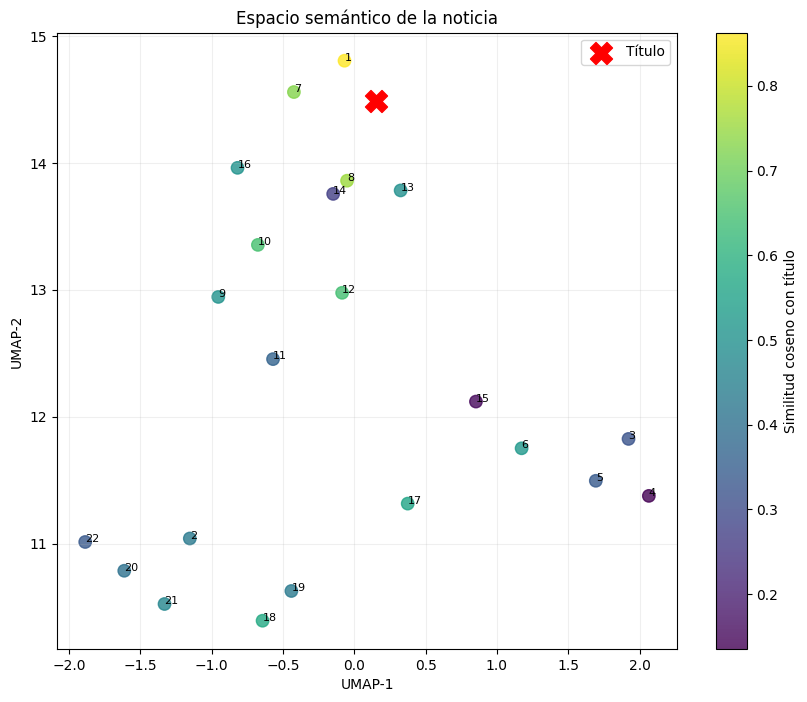

In [17]:
# corpus=cargar_datos(1)

similarities,embeddings=embedding_sentence_transformers(corpus)
embedding_2d=embedding_umap(similarities,embeddings, plot=True)

#### Embeding semántico + Features lingüísticos

Se ha decidido añadir un feature lingüístico con el objetivo de comparar el lenguaje emotivo/directo entre el título y el cuerpo de la noticia. Estos features capturan ese patrón: títulos con muchos deícticos y puntuación atraen pero el contenido es neutral.
Contadores de deícticos (yo, tú, él...), puntuación (!, ?, ¡¿) y superlativos (muy, increíblemente, -ísimo).

- Para que se puedan comparar el deícticos, puntuación y los superlativos se ha decidido normalizar con StandardScaler

- Se calcula el score como:
$$score=(1-similitud)\cdot diferencia_lingüística$$
De tal forma que si la similitud es 1 en el espacio embebido será 0.
Cuánto más sea la diferencia entre el título y el contenido mayor será el diferencia_lingüística.

De tal forma que solo será alto si ambas condiciones ocurren.

In [18]:
def analizar_clickbait(noticias, n_noticia, plot=False):
    """
    Combina embeddings semánticos con features lingüísticos para detectar clickbait
    input: noticias (list), n_noticia (int), plot (bool)
    output: score_medio (float), análisis (dict)
    """
    # 1. Cargar datos
    titulo, fragmentos, noticia = cargar_datos(noticias, n_noticia)
    periodico=noticia["Periódico"]
    categoria=noticia["Categoría"]
    link=noticia["Link"]
    clickbait=noticia["cb"]
    corpus = [titulo] + fragmentos
    
    # 2. Extraer features lingüísticos
    features_ling = extraer_features_linguisticos(corpus)
    diferencias_ling, (titulo_norm, fragmentos_norm) = calcular_diferencia_features(corpus)
    
    # 3. Embeddings semánticos
    similarities, embeddings = embedding_sentence_transformers(corpus)
    embedding_2d = embedding_umap(similarities, embeddings, plot=False)
    
    # 4. Normalizar features lingüísticos
    scaler = StandardScaler()
    features_norm = scaler.fit_transform(features_ling)
    titulo_features = features_norm[0]
    fragmentos_features = features_norm[1:]
    
    # 5. Distancia en espacio UMAP
    titulo_2d = embedding_2d[0]
    fragmentos_2d = embedding_2d[1:]
    dist_semantica = np.linalg.norm(fragmentos_2d - titulo_2d, axis=1)
    
    # 6. SCORE CLICKBAIT: (1 - similitud semántica) × distancia lingüística
    score_clickbait = (1 - similarities) * diferencias_ling
    score_medio = np.mean(score_clickbait)
    
    analisis = {
        'titulo': titulo,
        'periodico': periodico,
        'categoria': categoria,
        'link': link,
        'score_clickbait': score_clickbait,
        'score_medio': score_medio,
        'similitud_semantica': similarities,
        'diferencias_linguisticas': diferencias_ling,
        'dist_semantica': dist_semantica,
        'features_titulo': titulo_features,
        'features_fragmentos': fragmentos_features
    }
    
    if plot:
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        
        # Similitud semántica vs distancia lingüística
        axes[0, 0].scatter(similarities, diferencias_ling, s=100, alpha=0.6, color='purple')
        axes[0, 0].set_xlabel('Similitud Semántica')
        axes[0, 0].set_ylabel('Diferencia Lingüística')
        axes[0, 0].set_title('Relación Semántica-Lingüística')
        axes[0, 0].grid(alpha=0.2)
        
        # Score de clickbait por fragmento
        axes[0, 1].bar(range(len(score_clickbait)), score_clickbait, color='red', alpha=0.7)
        axes[0, 1].axhline(y=score_medio, color='darkred', linestyle='--', label=f'Media: {score_medio:.3f}')
        axes[0, 1].set_xlabel('Fragmento')
        axes[0, 1].set_ylabel('Score Clickbait')
        axes[0, 1].set_title('Puntuación de Clickbait por Fragmento')
        axes[0, 1].legend()
        axes[0, 1].grid(alpha=0.2)
        
        # Features: título vs fragmentos
        features_names = [
            'Deícticos',
            'Intensificadores',
            'Superlativos',
            'Emocionales',
            'CuriosityGap',
            'Exclamaciones',
            'Interrogaciones',
            #'PuntosSuspensivos',
            #'Mayúsculas',
            #'Números',
            'RatioDeícticos',
            'RatioIntensificadores',
            'RatioEmocionales',
            'RatioSuperlativos'
        ]
        x_pos = np.arange(len(features_names))
        titulo_vals = titulo_features
        fragmentos_vals = np.mean(fragmentos_features, axis=0)
        
        axes[1, 0].bar(x_pos - 0.2, titulo_vals, 0.4, label='Título', color='red', alpha=0.7)
        axes[1, 0].bar(x_pos + 0.2, fragmentos_vals, 0.4, label='Fragmentos (promedio)', color='blue', alpha=0.7)
        axes[1, 0].set_ylabel('Valor normalizado')
        axes[1, 0].set_title('Comparación de Features Lingüísticos')
        axes[1, 0].set_xticks(x_pos)
        axes[1, 0].set_xticklabels(features_names)
        axes[1, 0].legend()
        axes[1, 0].grid(alpha=0.2)
        
        # Espacio UMAP coloreado por score clickbait
        x = embedding_2d[:, 0]
        y = embedding_2d[:, 1]
        scatter = axes[1, 1].scatter(x[1:], y[1:], c=score_clickbait, cmap='RdYlGn_r', s=100, alpha=0.8)
        axes[1, 1].scatter(x[0], y[0], color='darkred', s=300, marker='X', label='Título')
        axes[1, 1].set_xlabel('UMAP-1')
        axes[1, 1].set_ylabel('UMAP-2')
        axes[1, 1].set_title('Espacio Semántico coloreado por Clickbait')
        axes[1, 1].legend()
        plt.colorbar(scatter, ax=axes[1, 1], label='Score Clickbait')
        
        plt.tight_layout()
        plt.show()
    
    return score_medio, analisis

Batches: 100%|██████████| 1/1 [00:00<00:00,  8.44it/s]
/home/javier/miniconda3/envs/NLP/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


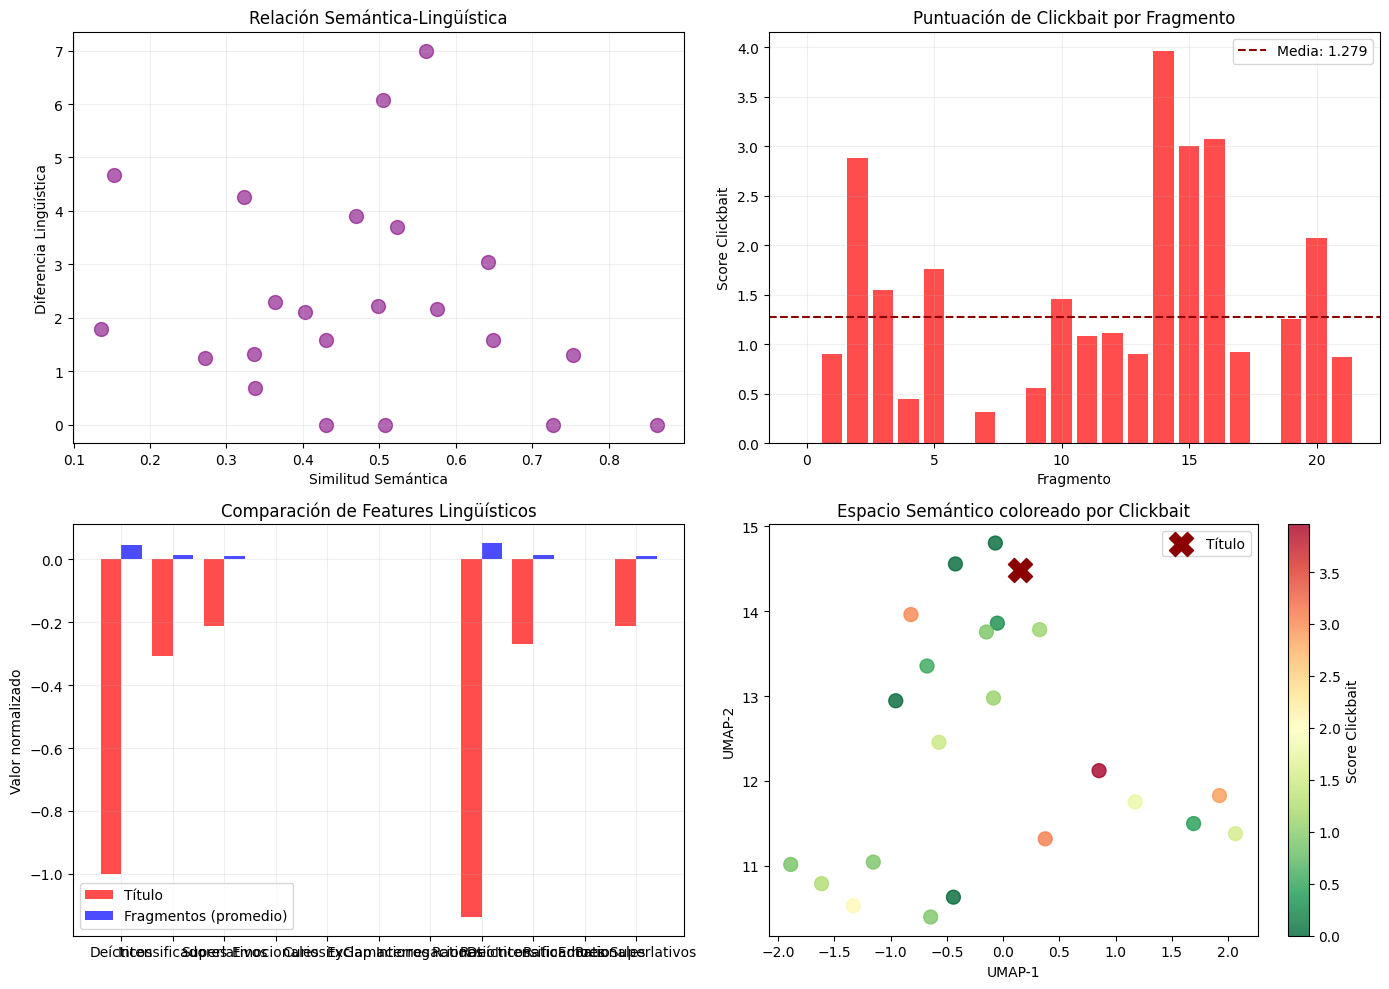

In [20]:
score, datos = analizar_clickbait(noticias, 5, plot=True)

Batches: 100%|██████████| 1/1 [00:00<00:00, 44.22it/s]
/home/javier/miniconda3/envs/NLP/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


✓ Noticia 0/62


Batches: 100%|██████████| 1/1 [00:00<00:00,  7.27it/s]
/home/javier/miniconda3/envs/NLP/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


✓ Noticia 1/62


Batches: 100%|██████████| 1/1 [00:00<00:00, 36.14it/s]
/home/javier/miniconda3/envs/NLP/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


...

✓ Noticia 60/62


Batches: 100%|██████████| 1/1 [00:00<00:00, 61.69it/s]
/home/javier/miniconda3/envs/NLP/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


✓ Noticia 61/62


Batches: 100%|██████████| 1/1 [00:00<00:00, 36.68it/s]
/home/javier/miniconda3/envs/NLP/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


✓ Noticia 62/62

ESTADÍSTICAS DE CLICKBAIT

📊 GENERAL:
  • Total noticias: 60
  • Score medio: 1.175
  • Score máximo: 3.925
  • Score mínimo: 0.130
  • Desviación estándar: 0.504

🏆 NOTICIAS CON MAYOR CLICKBAIT:
  46. [Internacional] el vicepresidente vance el primero en ser rescatado del tiro... (3.925)
  6. [Cultura] vuelve a editarse el último poemario que escribió miguel her... (1.924)
  18. [Internacional] no reciclar le costó a españa 686 millones de euros en 2023... (1.833)
  2. [Internacional] un tribunal de la haya ordena el embargo de la sede del inst... (1.759)
  36. [Internacional] trump dice que está sopesando retirar tropas de alemania por... (1.731)

📁 POR CATEGORÍA:
  • Internacional: 20 noticias, media=1.286
  • Nacional: 20 noticias, media=1.004
  • Cultura: 20 noticias, media=1.234

📰 POR PERIÓDICO:
  • 20minutos: 9 noticias, media=1.282
  • ABC: 8 noticias, media=1.060
  • El Confidencial: 9 noticias, media=0.925
  • La Vanguardia: 8 noticias, media=1.149
  • www.e

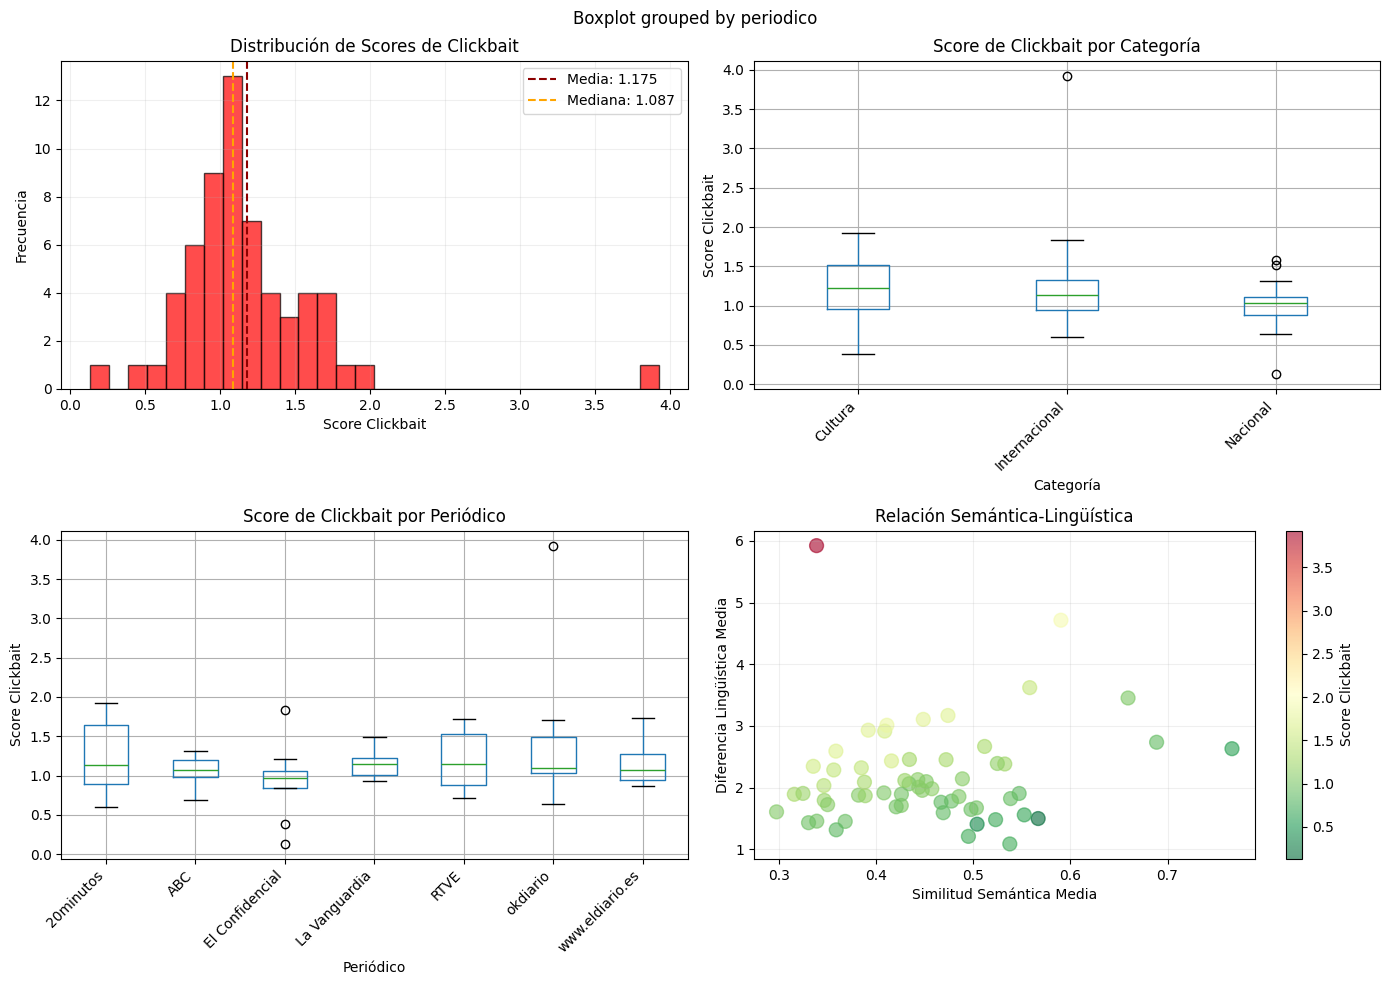

In [ ]:
# ESTE CÓDIGO NO ESTÁ BIEN MIRADO, SOLO ERAP ARA SACAR RESULTADOS RÁPIDOS DE LO ANTERIOR


def procesar_todas_noticias(noticias):
    """
    Procesa todas las noticias y calcula score de clickbait
    input: noticias (list)
    output: dataframe con scores y metadatos
    """
    resultados = []
    
    for n in range(len(noticias)):
        try:
            score_medio, analisis = analizar_clickbait(noticias, n, plot=False)
            
            noticia = noticias[n]
            resultados.append({
                'id_noticia': n,
                'titulo': noticia.get('Título', ''),
                'categoria': noticia.get('Categoría', ''),
                'periodico': noticia.get('Periódico', ''),
                'score_clickbait': score_medio,
                'similitud_media': np.mean(analisis['similitud_semantica']),
                'diferencia_ling_media': np.mean(analisis['diferencias_linguisticas']),
                'deicticos_titulo': analisis['features_titulo'][0],
                'puntuacion_titulo': analisis['features_titulo'][1],
                'superlativos_titulo': analisis['features_titulo'][2]
            })
            
            print(f"✓ Noticia {n}/{len(noticias)-1}")
        
        except Exception as e:
            print(f"✗ Error en noticia {n}: {e}")
    
    df = pd.DataFrame(resultados)
    return df


def visualizar_resultados_clickbait(df):
    """
    Visualiza histogramas y estadísticas de clickbait
    input: df (pandas DataFrame)
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. Histograma de scores
    axes[0, 0].hist(df['score_clickbait'], bins=30, color='red', alpha=0.7, edgecolor='black')
    axes[0, 0].axvline(df['score_clickbait'].mean(), color='darkred', linestyle='--', 
                       label=f'Media: {df["score_clickbait"].mean():.3f}')
    axes[0, 0].axvline(df['score_clickbait'].median(), color='orange', linestyle='--', 
                       label=f'Mediana: {df["score_clickbait"].median():.3f}')
    axes[0, 0].set_xlabel('Score Clickbait')
    axes[0, 0].set_ylabel('Frecuencia')
    axes[0, 0].set_title('Distribución de Scores de Clickbait')
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.2)
    
    # 2. Score por categoría
    df.boxplot(column='score_clickbait', by='categoria', ax=axes[0, 1])
    axes[0, 1].set_title('Score de Clickbait por Categoría')
    axes[0, 1].set_xlabel('Categoría')
    axes[0, 1].set_ylabel('Score Clickbait')
    plt.sca(axes[0, 1])
    plt.xticks(rotation=45, ha='right')
    
    # 3. Score por periódico
    df.boxplot(column='score_clickbait', by='periodico', ax=axes[1, 0])
    axes[1, 0].set_title('Score de Clickbait por Periódico')
    axes[1, 0].set_xlabel('Periódico')
    axes[1, 0].set_ylabel('Score Clickbait')
    plt.sca(axes[1, 0])
    plt.xticks(rotation=45, ha='right')
    
    # 4. Scatter: similitud vs diferencia lingüística
    scatter = axes[1, 1].scatter(df['similitud_media'], df['diferencia_ling_media'], 
                                c=df['score_clickbait'], cmap='RdYlGn_r', s=100, alpha=0.6)
    axes[1, 1].set_xlabel('Similitud Semántica Media')
    axes[1, 1].set_ylabel('Diferencia Lingüística Media')
    axes[1, 1].set_title('Relación Semántica-Lingüística')
    plt.colorbar(scatter, ax=axes[1, 1], label='Score Clickbait')
    axes[1, 1].grid(alpha=0.2)
    
    plt.tight_layout()
    plt.show()


def estadisticas_clickbait(df):
    """
    Imprime estadísticas generales
    input: df (pandas DataFrame)
    """
    print("\n" + "="*80)
    print("ESTADÍSTICAS DE CLICKBAIT")
    print("="*80)
    
    print(f"\n📊 GENERAL:")
    print(f"  • Total noticias: {len(df)}")
    print(f"  • Score medio: {df['score_clickbait'].mean():.3f}")
    print(f"  • Score máximo: {df['score_clickbait'].max():.3f}")
    print(f"  • Score mínimo: {df['score_clickbait'].min():.3f}")
    print(f"  • Desviación estándar: {df['score_clickbait'].std():.3f}")
    
    print(f"\n🏆 NOTICIAS CON MAYOR CLICKBAIT:")
    top_5 = df.nlargest(5, 'score_clickbait')[['id_noticia', 'titulo', 'categoria', 'score_clickbait']]
    for idx, row in top_5.iterrows():
        print(f"  {row['id_noticia']}. [{row['categoria']}] {row['titulo'][:60]}... ({row['score_clickbait']:.3f})")
    
    print(f"\n📁 POR CATEGORÍA:")
    for cat in df['categoria'].unique():
        df_cat = df[df['categoria'] == cat]
        print(f"  • {cat}: {len(df_cat)} noticias, media={df_cat['score_clickbait'].mean():.3f}")
    
    print(f"\n📰 POR PERIÓDICO:")
    for per in df['periodico'].unique():
        df_per = df[df['periodico'] == per]
        print(f"  • {per}: {len(df_per)} noticias, media={df_per['score_clickbait'].mean():.3f}")


# USO
df_resultados = procesar_todas_noticias(noticias)
estadisticas_clickbait(df_resultados)
visualizar_resultados_clickbait(df_resultados)

# Guardar resultados
df_resultados.to_csv('resultados_clickbait.csv', index=False)

### Cross encoder (MEJOR NO)

In [13]:
# corpus=cargar_datos(1)

probabilities = embedding_cross_encoder(corpus)

Loading weights: 100%|██████████| 105/105 [00:00<00:00, 1593.63it/s]


In [14]:
probabilities

array([9.9990332e-01, 1.3110045e-01, 2.7596576e-05, 2.1976733e-03,
       1.2876525e-05, 1.7030254e-05, 3.5303498e-03, 7.2955912e-01,
       1.8634187e-01, 1.1990397e-01, 3.8818934e-04], dtype=float32)

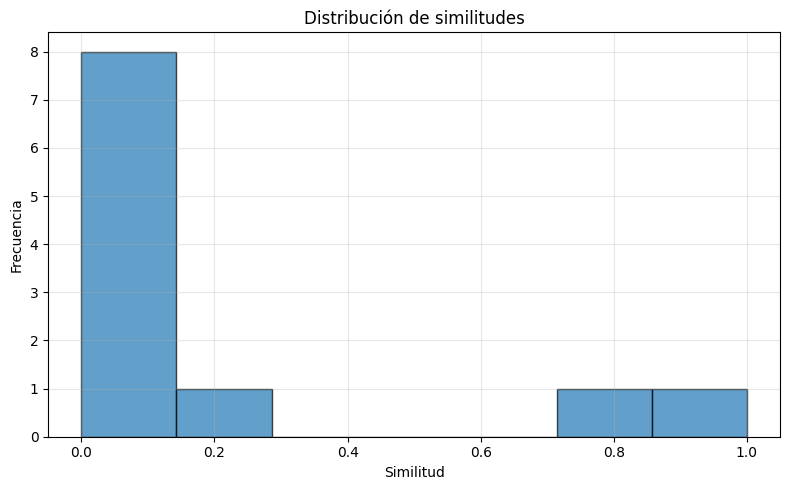

In [15]:



plt.figure(figsize=(8, 5))

plt.hist(
    probabilities,
    bins=7,          # Número de bins
    edgecolor='black',
    alpha=0.7
)

plt.xlabel("Similitud")
plt.ylabel("Frecuencia")
plt.title("Distribución de similitudes")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**PRUEBAS**

----

In [16]:
import numpy as np
import pandas as pd

# =========================
# Parámetros globales
# =========================

N_ARCHIVOS = 63 # ajusta a tu caso

resultados = []

# =========================
# Loop sobre noticias
# =========================

for i in range(N_ARCHIVOS):

    try:
        noticia, corpus = cargar_datos(i)
        categoria=noticia["Categoría"]
        periodico=noticia["Periódico"]
        similarities, embeddings = embedding_sentence_transformers(corpus)

        similarities = np.array(similarities)

        # =========================
        # Métricas básicas
        # =========================

        media = similarities.mean()
        std = similarities.std()
        minimo = similarities.min()
        maximo = similarities.max()

        # porcentaje de frases relevantes
        umbral = 0.6
        relevancia = np.mean(similarities > umbral)

        # entropía (versión simple con softmax)
        exp_sim = np.exp(similarities)
        probs = exp_sim / np.sum(exp_sim)

        entropia = -np.sum(probs * np.log(probs + 1e-12))

        resultados.append({
            "id": i,
            "categoría": categoria,
            "periódico": periodico,
            "media_sim": media,
            "std_sim": std,
            "min_sim": minimo,
            "max_sim": maximo,
            "ratio_relevante": relevancia,
            "entropia": entropia
        })

    except Exception as e:
        print(f"Error en archivo {i}: {e}")

# =========================
# DataFrame final
# =========================

df = pd.DataFrame(resultados)

print(df.head())

# =========================
# Estadísticas globales
# =========================

print("\nResumen global:")
print(df.describe())

Batches: 100%|██████████| 1/1 [00:00<00:00, 33.55it/s]

   id      categoría  periódico  media_sim   std_sim   min_sim   max_sim  \
0   0  Internacional  20minutos   0.766291  0.044968  0.721323  0.811259   
1   1  Internacional  20minutos   0.443021  0.124735  0.262950  0.675514   
2   2  Internacional  20minutos   0.448650  0.182501  0.288300  0.703970   
3   3       Nacional  20minutos   0.477700  0.118087  0.210933  0.666458   
4   4       Nacional  20minutos   0.547311  0.182992  0.376594  0.918128   

   ratio_relevante  entropia  
0         1.000000  0.692137  
1         0.192308  3.250077  
2         0.333333  1.080901  
3         0.200000  2.701162  
4         0.375000  2.061020  

Resumen global:
              id  media_sim    std_sim    min_sim    max_sim  ratio_relevante  \
count  63.000000  63.000000  63.000000  63.000000  63.000000        63.000000   
mean   31.000000   0.461090   0.150547   0.226746   0.745232         0.231510   
std    18.330303   0.106537   0.067968   0.182746   0.109271         0.258913   
min     0.000000

In [17]:
df

,id,categoría,periódico,media_sim,std_sim,min_sim,max_sim,ratio_relevante,entropia
0,0,Internacional,20minutos,0.766291,0.044968,0.721323,0.811259,1.000000,0.692137
1,1,Internacional,20minutos,0.443021,0.124735,0.262950,0.675514,0.192308,3.250077
2,2,Internacional,20minutos,0.448650,0.182501,0.288300,0.703970,0.333333,1.080901
3,3,Nacional,20minutos,0.477700,0.118087,0.210933,0.666458,0.200000,2.701162
4,4,Nacional,20minutos,0.547311,0.182992,0.376594,0.918128,0.375000,2.061020
...,...,...,...,...,...,...,...,...,...
58,58,Nacional,RTVE,0.558173,0.124761,0.433412,0.682933,0.500000,0.685425
59,59,Nacional,RTVE,0.335473,0.171560,0.176686,0.724698,0.125000,2.062498
60,60,Cultura,RTVE,0.511739,0.014208,0.497531,0.525948,0.000000,0.693046
61,61,Cultura,RTVE,0.538437,0.042570,0.492995,0.595357,0.000000,1.097697


<Axes: >

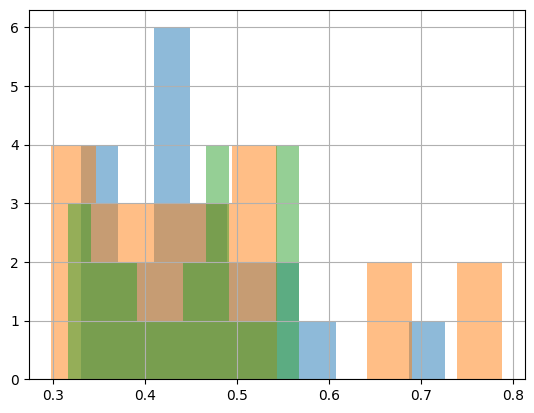

In [18]:
# df["media_sim"].hist()
df[df["categoría"]=="Cultura"]["media_sim"].hist(alpha=0.5, label="Cultura")
df[df["categoría"]=="Internacional"]["media_sim"].hist(alpha=0.5, label="Internacional")
df[df["categoría"]=="Nacional"]["media_sim"].hist(alpha=0.5, label="Nacional")

<Axes: >

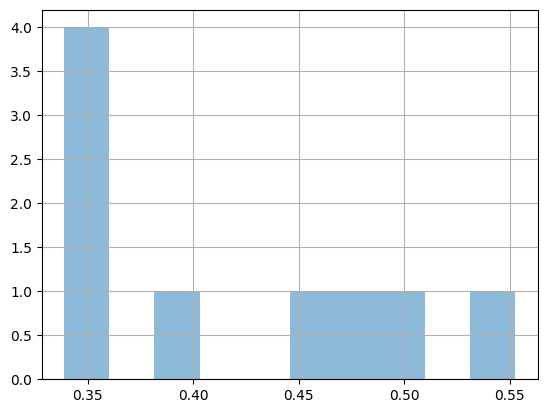

In [19]:
# df[df["periódico"]=="20minutos"]["media_sim"].hist(alpha=0.5, label="Cultura")
df[df["periódico"]=="okdiario"]["media_sim"].hist(alpha=0.5, label="Cultura")
# df[df["periódico"]=="RTVE"]["media_sim"].hist(alpha=0.5, label="Cultura")





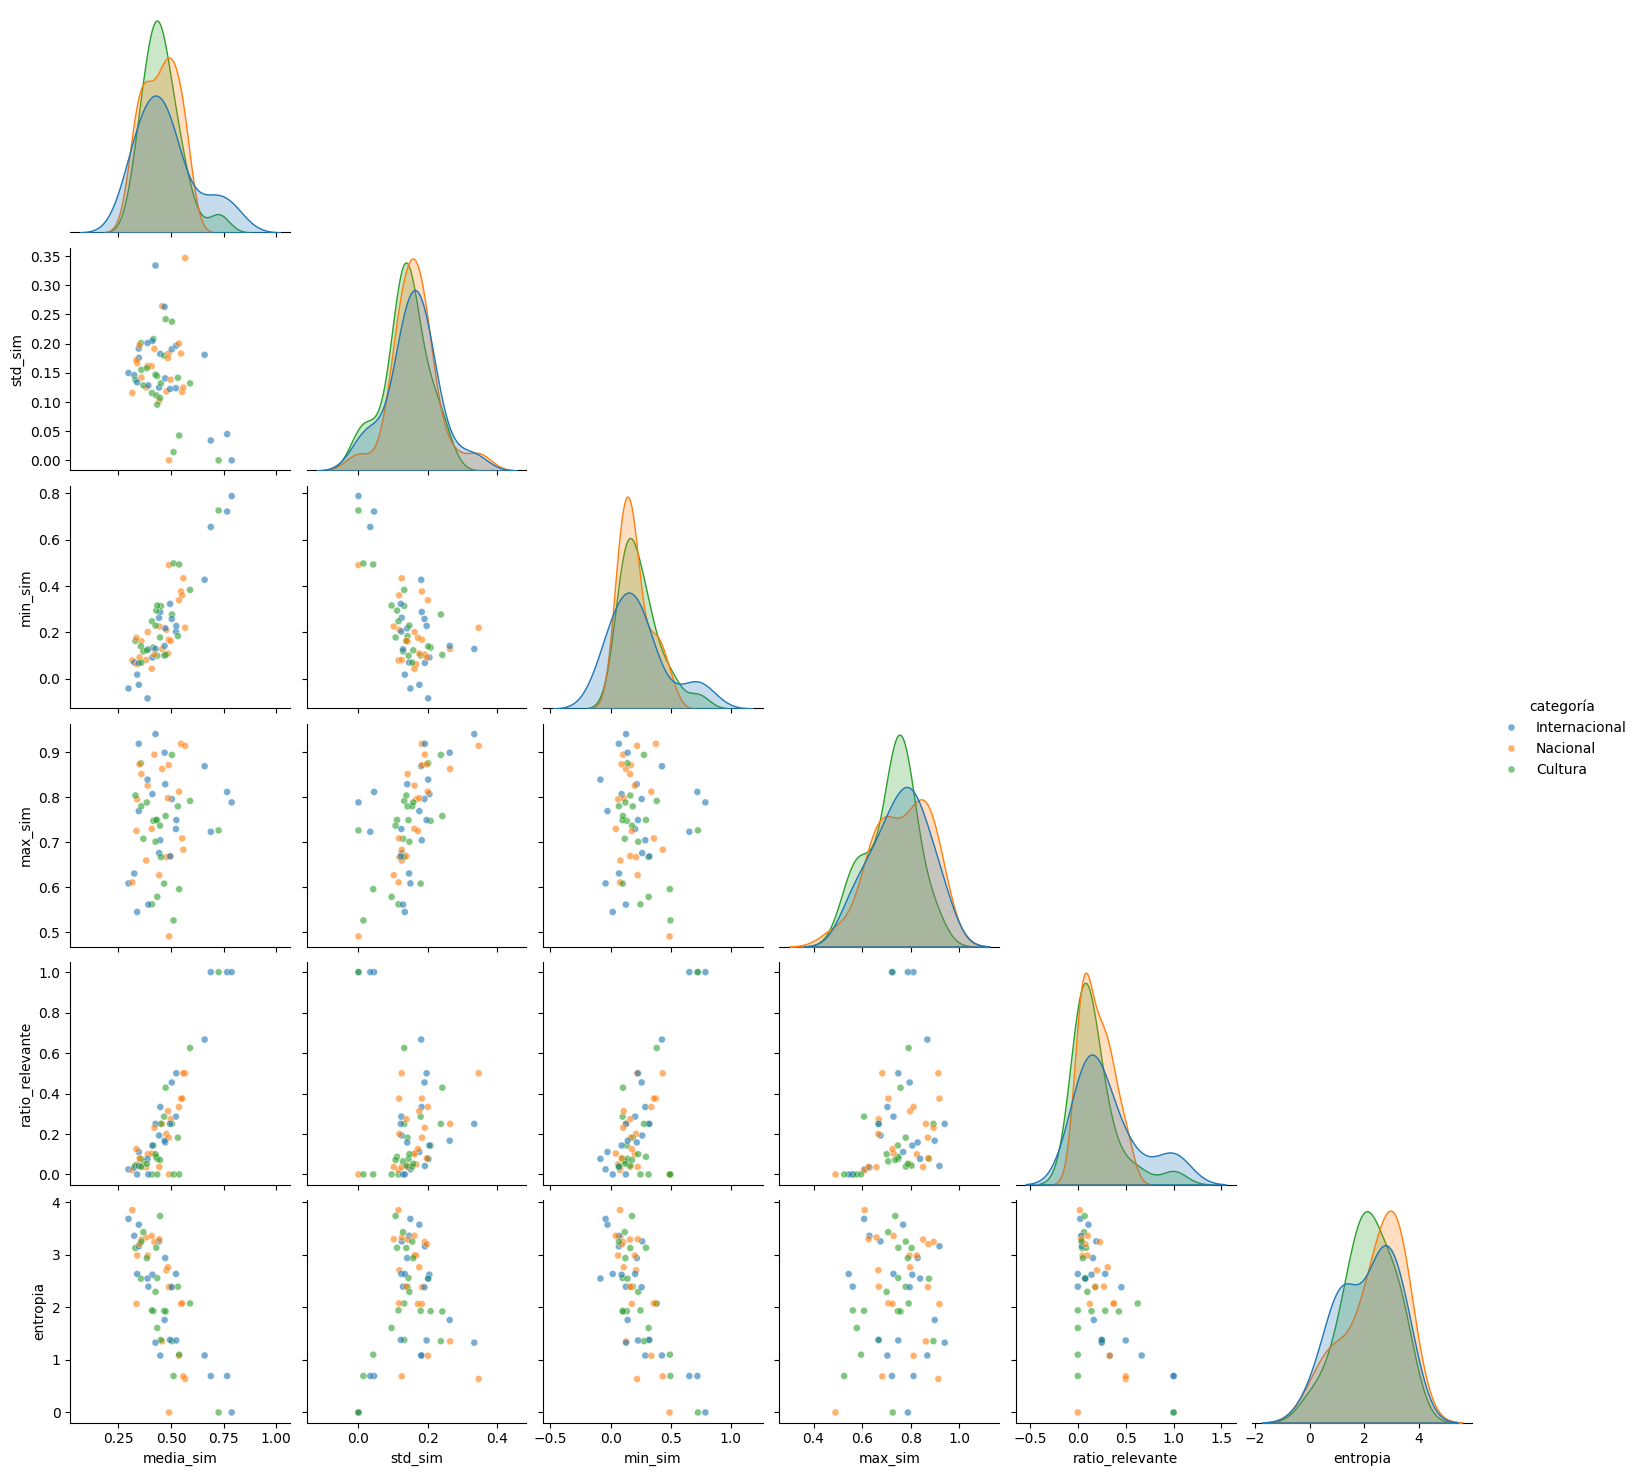

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# =========================
# Selección de variables
# =========================

cols = [
    "media_sim",
    "std_sim",
    "min_sim",
    "max_sim",
    "ratio_relevante",
    "entropia"
]

# =========================
# Pairplot
# =========================

sns.pairplot(
    df[cols + ["categoría"]],
    hue="categoría",
    diag_kind="kde",
    corner=True,
    plot_kws={"alpha": 0.6, "s": 25}
)

plt.show()

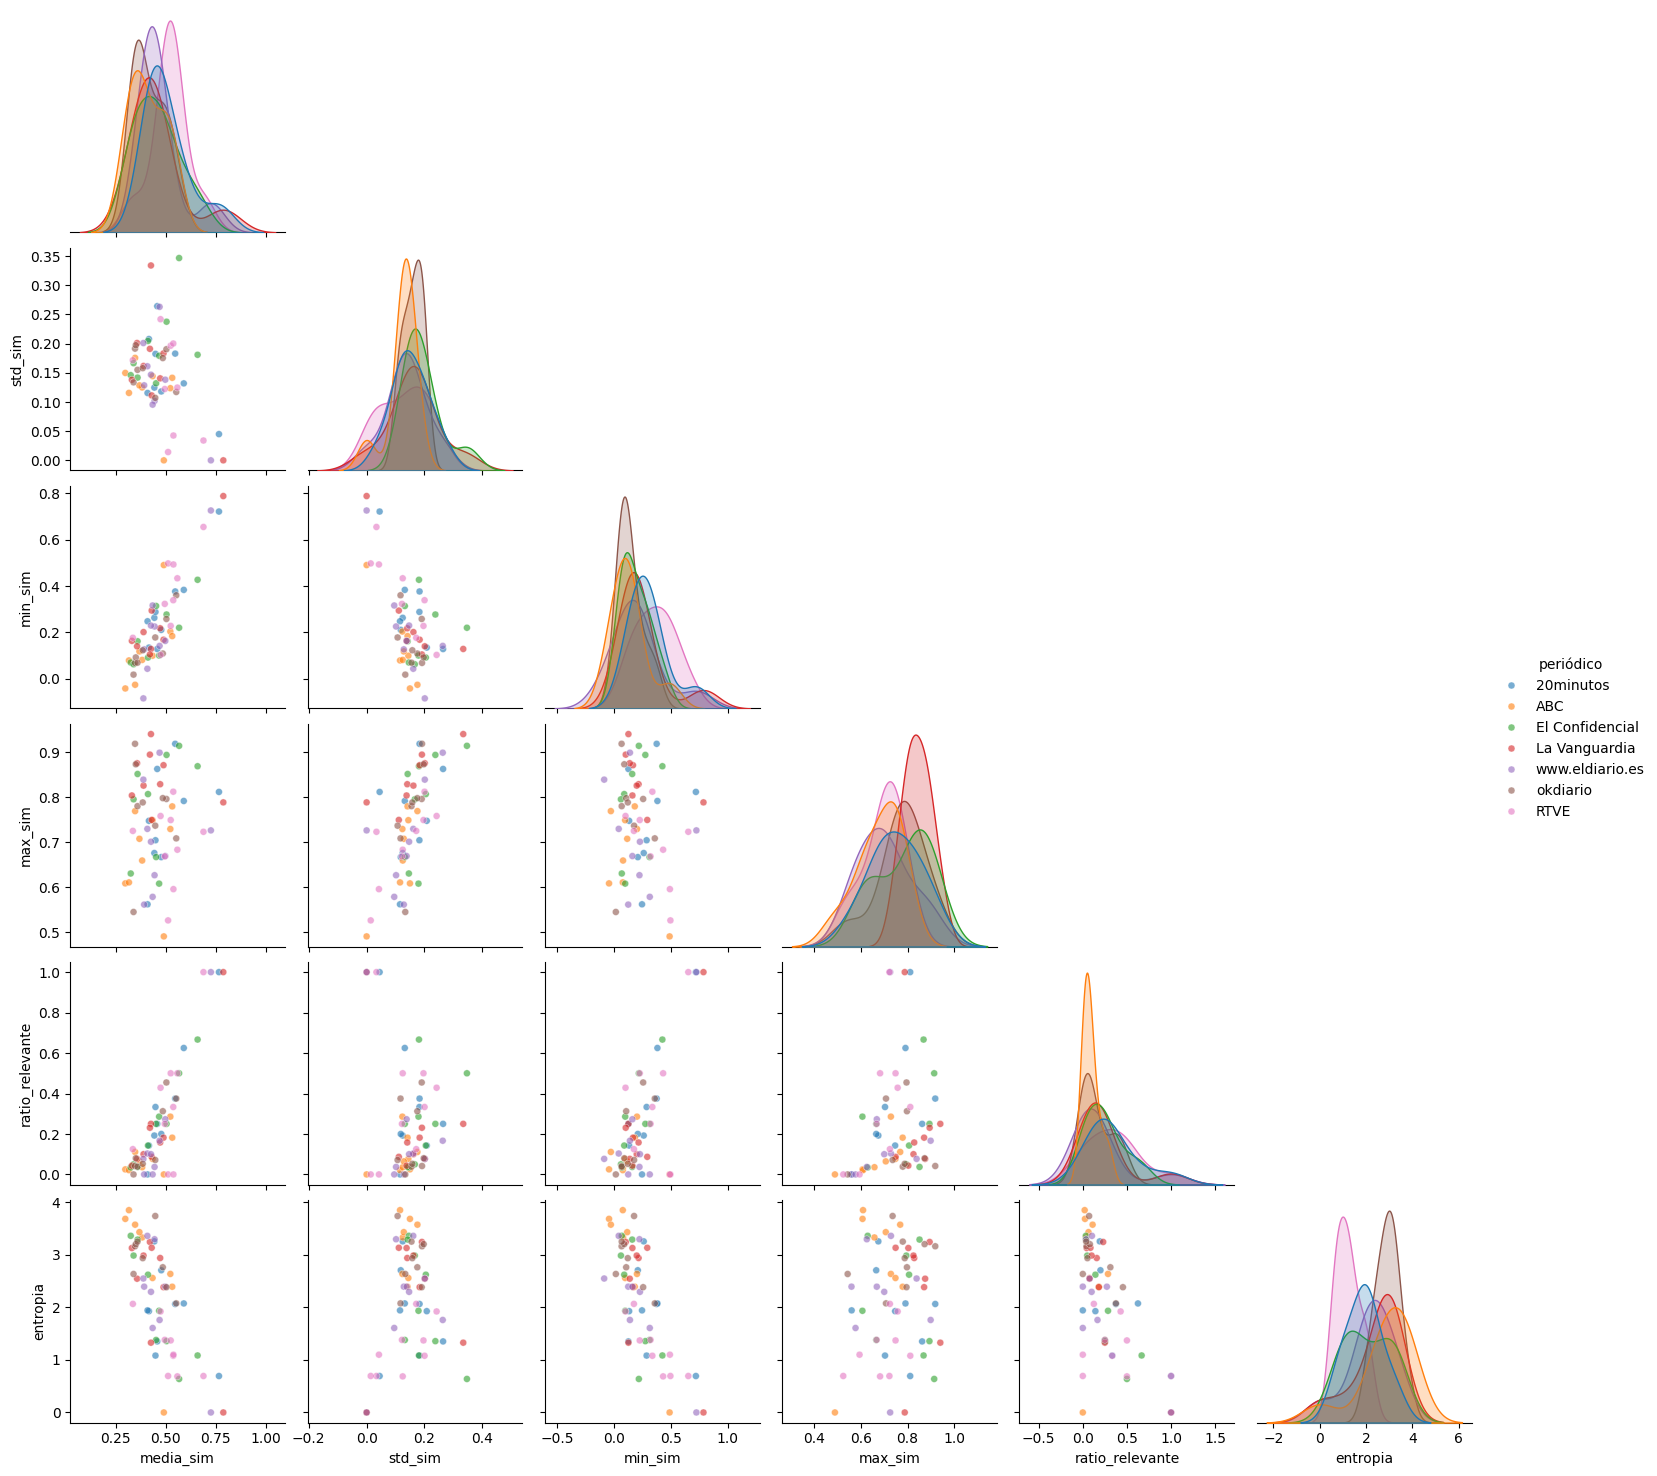

In [21]:
cols = [
    "media_sim",
    "std_sim",
    "min_sim",
    "max_sim",
    "ratio_relevante",
    "entropia"
]

# =========================
# Pairplot
# =========================

sns.pairplot(
    df[cols + ["periódico"]],
    hue="periódico",
    diag_kind="kde",
    corner=True,
    plot_kws={"alpha": 0.6, "s": 25}
)

plt.show()

### Question Answering (QA)

Convertir el titular en una pregunta con un transformers de QA y ver si encuentra la respuesta en qué frase del texto, si es al final del texto o no aparece puede dar indicios de clickbait



### Buscar si el cuerpo aporta más información (entropía)

Hipótesis: El contenido en noticias con clickbait tienen una tasa de redundancia muy alta. Dice mucho en el título y casi nada de información nueva en el contenido (entropía baja)